<a href="https://colab.research.google.com/github/vaishnavichaudhary2812-sudo/SCT_DS_01/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import pandas as pd

In [2]:
zip_path = "/content/API_SP.POP.TOTL_DS2_EN_csv_v2_327505.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/population_data")

In [3]:
import os

os.listdir("/content/population_data")

['API_SP.POP.TOTL_DS2_EN_csv_v2_327505.csv',
 'Metadata_Indicator_API_SP.POP.TOTL_DS2_EN_csv_v2_327505.csv',
 'Metadata_Country_API_SP.POP.TOTL_DS2_EN_csv_v2_327505.csv']

In [4]:
df = pd.read_csv(
    "/content/population_data/API_SP.POP.TOTL_DS2_EN_csv_v2_327505.csv",
    skiprows=4
)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


In [5]:
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [6]:
population = df[['Country Name','2022']]
population.head()

,Country Name,2022
0,Aruba,107310.0
1,Africa Eastern and Southern,731821393.0
2,Afghanistan,40578842.0
3,Africa Western and Central,497387180.0
4,Angola,35635029.0


In [7]:
population = population.dropna()

In [8]:
population.isnull().sum()

,0
Country Name,0
2022,0


In [16]:
population = df[['Country Name', '2024']]
population = population.rename(columns={'2024':'Population'})
population.head()

,Country Name,Population
0,Aruba,107995.0
1,Africa Eastern and Southern,769280888.0
2,Afghanistan,42647492.0
3,Africa Western and Central,521764076.0
4,Angola,37885849.0


In [20]:
!pip install plotly

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [27]:
fig = px.histogram(
    population,
    x='Population',
    nbins=40,
    title='Distribution of World Population by Country',
    template='plotly_dark'
)

fig.update_layout(
    xaxis_title='Population',
    yaxis_title='Number of Countries'
)

fig.show()

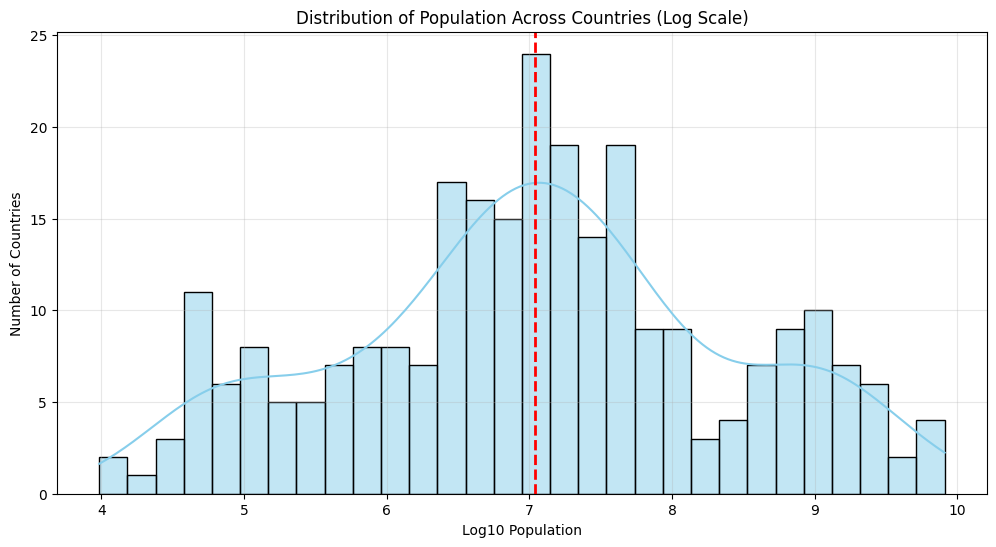

In [26]:
import numpy as np

population['Log_Population'] = np.log10(population['Population'])

plt.figure(figsize=(12,6))

sns.histplot( population['Log_Population'], bins=30,kde=True, color='skyblue')

plt.axvline(population['Log_Population'].mean(), color='red', linestyle='dashed', linewidth=2)

plt.title("Distribution of Population Across Countries (Log Scale)")
plt.xlabel("Log10 Population")
plt.ylabel("Number of Countries")

plt.grid(True, alpha=0.3)
plt.show()